# Atividade 03
##### Miguel Antunes Vilela - 10769607

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

### Contexto
Uma empresa de RH coletou dados de funcionários contendo anos de experiência profissional e o respectivo salário mensal (R$mil). Sabe-se que a base contém registros inconsistentes (outliers) provenientes de erros de digitação e casos extremos.

#### Funções Auxiliares
Funções reutilizadas ao longo do laboratório: resumo estatístico, assimetria, ajuste da regressão e
gráfico da reta ajustada.

In [43]:
def skewness(x):
    """Assimetria (skewness) amostral."""
    x = np.asarray(x)
    m, s, n = x.mean(), x.std(ddof=1), len(x)
    return (np.sum((x- m) ** 3) / n) / s ** 3

def summary(x):
    """Resumo equivalente ao summary() do R."""
    q = np.quantile(x, [0, 0.25, 0.5, 0.75, 1])
    return pd.Series([q[0], q[1], q[2], np.mean(x), q[3], q[4]], index=["Min.", "1st Qu.", "Median", "Mean", "3rd Qu.", "Max."],).round(3)

def descrever(serie, nome):
    """Imprime o resumo estatístico e a assimetria de uma variável."""
    print(f"  {nome} " + " " * (42- len(nome)))
    print(summary(serie).to_string())
    print(f"Assimetria (Skewness) : {skewness(serie):.2f}\n")

def ajustar_regressao(dados):
    """Ajusta Salario ~ Experiencia e devolve coeficientes e métricas."""
    ajuste = stats.linregress(dados["Experiencia"], dados["Salario"])
    b0, b1 = ajuste.intercept, ajuste.slope
    residuos = dados["Salario"]- (b0 + b1 * dados["Experiencia"])
    return {
    "b0":   b0,
    "b1":   b1,
    "r2":   ajuste.rvalue ** 2,
    "rmse": np.sqrt(np.mean(residuos ** 2)),
    "n":    len(dados),
    }

def predict(modelo, x):
    """Salário estimado pelo modelo para a experiência x."""
    return modelo["b0"] + modelo["b1"] * np.asarray(x)

def imprimir_modelo(modelo, titulo):
    """Resumo numérico do modelo ajustado."""
    print("=" * 46)
    print(f" {titulo}")
    print("=" * 46)
    print(f" Intercepto (  ) : {modelo['b0']:.4f}")
    print(f" Coeficiente (  ) : {modelo['b1']:.4f}")
    print(f" Equação    : Salário = {modelo['b0']:.2f} + {modelo['b1']:.4f} × Experiência")
    print(f" R²         : {modelo['r2']:.4f}")
    print(f" RMSE       : {modelo['rmse']:.4f} R$ mil")
    print("=" * 46)

def grafico_regressao(ax, dados, modelo, cor_pontos, cor_reta, titulo, equacao=True, alpha=0.55):
    """Dispersão com a reta de regressão ajustada."""
    x = dados["Experiencia"]
    ax.scatter(x, dados["Salario"], color=cor_pontos, alpha=alpha, s=20)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, predict(modelo, xs), color=cor_reta, linewidth=1.8)
    if equacao:
        ax.text(
        x.min() + np.ptp(x) * 0.05,
        dados["Salario"].max() * 0.95,
        rf"$\hat{{y}} = {modelo['b0']:.2f} + {modelo['b1']:.4f}\,x$",
        color=cor_reta,fontsize=11,va="top",
        bbox=dict(boxstyle="round",facecolor="white",alpha=0.85,
        edgecolor=cor_reta),
        )
    ax.set_title(titulo)
    ax.set_xlabel("Experiência(anos)")
    ax.set_ylabel("Salário(R$mil)")

def histograma(dados, n_bins,cor_barras,cor_densidade,titulo):
    """Histograma comacurvadedensidade(KDE)escaladaparacontagens."""
    x = dados["Experiencia"]
    bw = np.ptp(x)/ n_bins
    bins = np.arange(x.min(),x.max()+ bw,bw)
    fig,ax = plt.subplots()
    ax.hist(x, bins=bins,color=cor_barras,edgecolor="white")
    kde = stats.gaussian_kde(x)
    xs = np.linspace(x.min(),x.max(),300)
    ax.plot(xs,kde(xs) *len(x)* bw,color=cor_densidade,linewidth=2)
    ax.set_title(titulo)
    ax.set_xlabel("Experiência(anos)")
    ax.set_ylabel("Frequência")
    plt.show()

def tabela_markdown(dados,alinhamento,legenda):
    """ExibeumDataFramecomotabelaMarkdown(renderizaemHTMLePDF)."""
    marca = {"l": ":---","c": ":---:", "r":"---:"}
    linhas = ["|" + " | ".join(dados.columns) +" |", "|"+ "|".join(marca[a]for a in alinhamento)+ "|"]
    linhas += ["| " +" | ".join(str(v)for v in linha) + " |" for linha in dados.itertuples(index=False)]
    display(Markdown("\n".join(linhas) +f"\n\n:{legenda}"))

#### Questão 1: Detecção de Outliers e Regressão Linear
##### 1.1: Preparação e simulação de dados
 Criamos uma base com 150 funcionários, cuja experiência segue distribuição Normal (𝜇=8, 𝜎=3), e injetamos 20 registros atípicos (outliers) — 10 comexperiência muito baixa e 10 com experiência exagerada. O salário obedece à relação linear:
    Salário = 1,8 × Experiência + 4 + 𝜀, 𝜀∼𝒩(0, 1,5)

*Nota: esse arquivo segue o roteiro da aula, contendo conclusões originais na conclusão de cada um dos dois exercícios.*

In [44]:
rng= np.random.default_rng(7)

#150 registros normais:média = 8 anos, dp = 3 anos
exp_normal = rng.normal(loc=8,scale=3,size=150)
exp_normal = np.clip(exp_normal,0.5,25) #limita ao intervalo plausível
#20 outliers
outliers_baixos = rng.uniform(0.1, 0.5,size=10) #quase sem experiência
outliers_altos = rng.uniform(35,50,size=10) #experiência implausível
#Dataset completo com 170 registros
experiencia = np.concatenate([exp_normal,outliers_baixos,outliers_altos])
df = pd.DataFrame({"Experiencia":experiencia})
#Relação linear: Salário(R$mil)=1.8×Experiência+4 (+ ruído)
df["Salario"] = 1.8 *df["Experiencia"] + 4 + rng.normal(0,1.5,size=len(df))
print(f"Dataset criado com {len(df)} registros na amostra.")

Dataset criado com 170 registros na amostra.


##### 1.2: Análise exploratória (Dados Brutos)
Resumo estatístico e assimetria das variáveis Experiência e Salário.

In [45]:
descrever(df["Experiencia"], "Experiência(anos)")
descrever(df["Salario"], "Salário(R$mil)")

  Experiência(anos)                          
Min.        0.120
1st Qu.     5.474
Median      7.655
Mean        9.243
3rd Qu.     9.745
Max.       49.420
Assimetria (Skewness) : 3.11

  Salário(R$mil)                             
Min.        2.843
1st Qu.    13.744
Median     17.798
Mean       20.539
3rd Qu.    21.726
Max.       94.876
Assimetria (Skewness) : 3.12



##### 1.3: Histograma Original (Com Outliers)
Observe como a cauda do histograma se estende para os extremos — sinal claro da presença de
outliers.

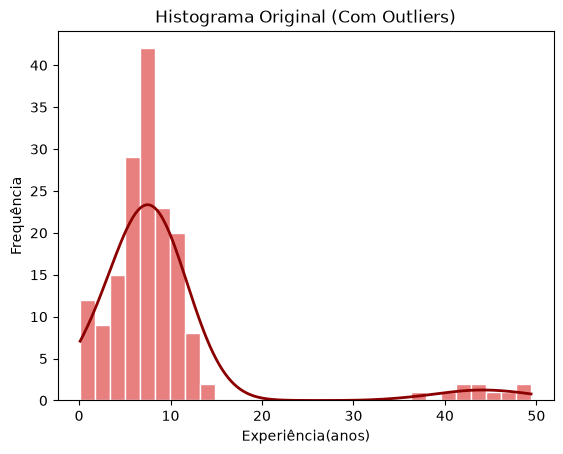

In [46]:
histograma(df, n_bins=30, cor_barras="#e88080", cor_densidade="darkred", titulo="Histograma Original (Com Outliers)")

##### 1.4: Dispersão Experiência × Salário (Com Outliers)


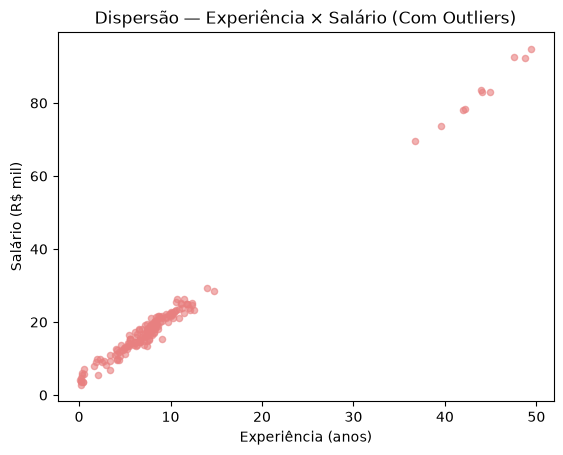

In [47]:
fig, ax = plt.subplots()
ax.scatter(df["Experiencia"], df["Salario"], color="#e88080", alpha=0.6, s=20)
ax.set_title("Dispersão — Experiência × Salário (Com Outliers)")
ax.set_xlabel("Experiência (anos)")
ax.set_ylabel("Salário (R$ mil)")
plt.show()

##### 1.5: Regressão Linear — Dados COM Outliers
Antes de tratar os outliers, ajustamos o modelo para observar como os valores extremos distorcem os coeficientes e a qualidade do ajuste.

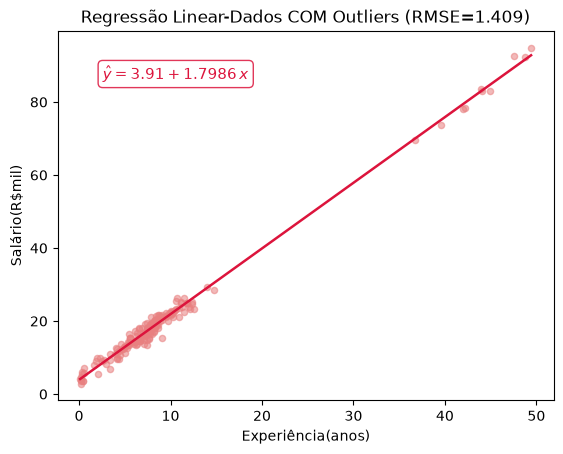

 REGRESSÃO LINEAR - COM OUTLIERS
 Intercepto (  ) : 3.9143
 Coeficiente (  ) : 1.7986
 Equação    : Salário = 3.91 + 1.7986 × Experiência
 R²         : 0.9928
 RMSE       : 1.4095 R$ mil


In [48]:
modelo_bruto = ajustar_regressao(df)
fig,ax = plt.subplots()
grafico_regressao(ax, df, modelo_bruto, cor_pontos="#e88080", cor_reta="#DC143C", titulo=f"Regressão Linear-Dados COM Outliers (RMSE={modelo_bruto['rmse']:.3f})",)
plt.show()
imprimir_modelo(modelo_bruto,"REGRESSÃO LINEAR - COM OUTLIERS")

##### 1.6:  Detecção de Outliers com Boxplot e AIQ
O método do AIQ (Amplitude Inter-Quartil) define limites para o que é considerado um dado típico,
ou seja, pode ser usado para detectar dados atípicos (outliers):

/tmp/ipykernel_7913/1254306357.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


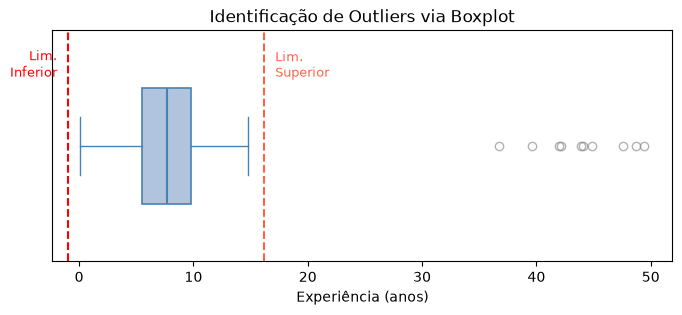

Intervalo AIQ: [-0.93 a 16.15]anos


In [49]:
Q1 = df["Experiencia"].quantile(0.25)
Q3 = df["Experiencia"].quantile(0.75)
AIQ = Q3- Q1
lim_inferior = Q1- 1.5 * AIQ
lim_superior = Q3 + 1.5 * AIQ
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(
df["Experiencia"],vert=False,widths=0.5,patch_artist=True,
boxprops=dict(facecolor="lightsteelblue",color="steelblue",linewidth=1.2),
medianprops=dict(color="steelblue",linewidth=1.5),
whiskerprops=dict(color="steelblue"),capprops=dict(color="steelblue"),
flierprops=dict(marker="o",markerfacecolor="none",
markeredgecolor="gray",alpha=0.6),
)
ax.axvline(lim_inferior,color="red",linestyle="--",linewidth=1.5)
ax.axvline(lim_superior,color="tomato",linestyle="--",linewidth=1.5)
ax.text(lim_inferior-1,1.3, "Lim.\nInferior",color="red",fontsize=9,ha="right")
ax.text(lim_superior +1,1.3, "Lim.\nSuperior",color="tomato",fontsize=9,ha="left")
ax.set_yticks([])
ax.grid(axis="y",visible=False)
ax.set_title("Identificação de Outliers via Boxplot")
ax.set_xlabel("Experiência (anos)")
plt.show()
print(f"Intervalo AIQ: [{lim_inferior:.2f} a {lim_superior:.2f}]anos")

##### 1.7: Eliminação de Outliers
Removemos todos os registros fora dos limites calculados pelo método AIQ.

In [50]:
df_limpo =df[(df["Experiencia"]>= lim_inferior) & (df["Experiencia"]<= lim_superior)].reset_index(drop=True)
removidos = len(df)- len(df_limpo)
print(f"Total de registros removidos: {removidos}")
print(f"Registros restantes: {len(df_limpo)}")

Total de registros removidos: 10
Registros restantes: 160


##### 1.8: Análise Exploratória (Dados Limpos)


In [51]:
descrever(df_limpo["Experiencia"], "Experiência (anos)")
descrever(df_limpo["Salario"], "Salário (R$ mil)")

  Experiência (anos)                         
Min.        0.120
1st Qu.     5.321
Median      7.455
Mean        7.077
3rd Qu.     9.044
Max.       14.734
Assimetria (Skewness) : -0.38

  Salário (R$ mil)                           
Min.        2.843
1st Qu.    13.489
Median     17.136
Mean       16.640
3rd Qu.    21.143
Max.       29.260
Assimetria (Skewness) : -0.41



##### 1.9: Histograma Pós-Tratamento (Dados Limpos)
Com os dados tratados, a distribuição de experiência revela o perfil real dos funcionários.

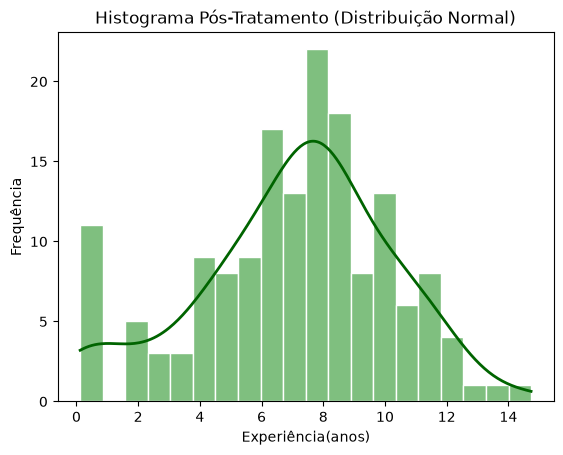

In [52]:
histograma(df_limpo, n_bins=20, cor_barras="#7fbf7f", cor_densidade="darkgreen", titulo="Histograma Pós-Tratamento (Distribuição Normal)")

##### 1.10: Regressão Linear — Dados SEM Outliers
Após a remoção dos outliers, ajustamos novamente o modelo para comparar com os resultados
anteriores.

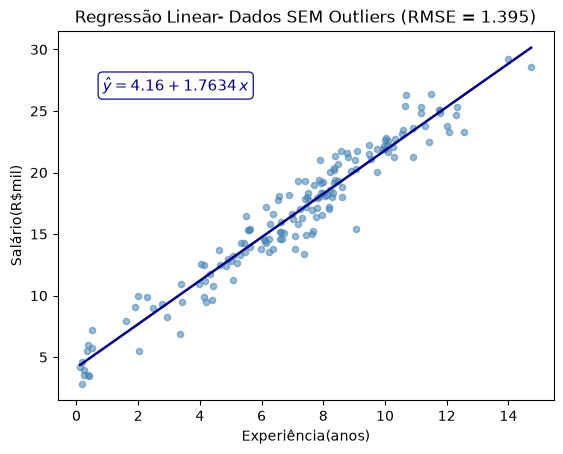

 REGRESSÃO LINEAR- SEM OUTLIERS
 Intercepto (  ) : 4.1607
 Coeficiente (  ) : 1.7634
 Equação    : Salário = 4.16 + 1.7634 × Experiência
 R²         : 0.9393
 RMSE       : 1.3952 R$ mil


In [53]:
modelo_limpo = ajustar_regressao(df_limpo)
fig, ax = plt.subplots()
grafico_regressao(
ax, df_limpo, modelo_limpo, cor_pontos="steelblue", cor_reta="navy",
titulo=f"Regressão Linear- Dados SEM Outliers (RMSE = {modelo_limpo['rmse']:.3f})",
)
plt.show()

imprimir_modelo(modelo_limpo, "REGRESSÃO LINEAR- SEM OUTLIERS")

##### 1.11: Comparação dos Modelos
Visualização lado a lado e tabela comparativa para evidenciar o impacto dos outliers.

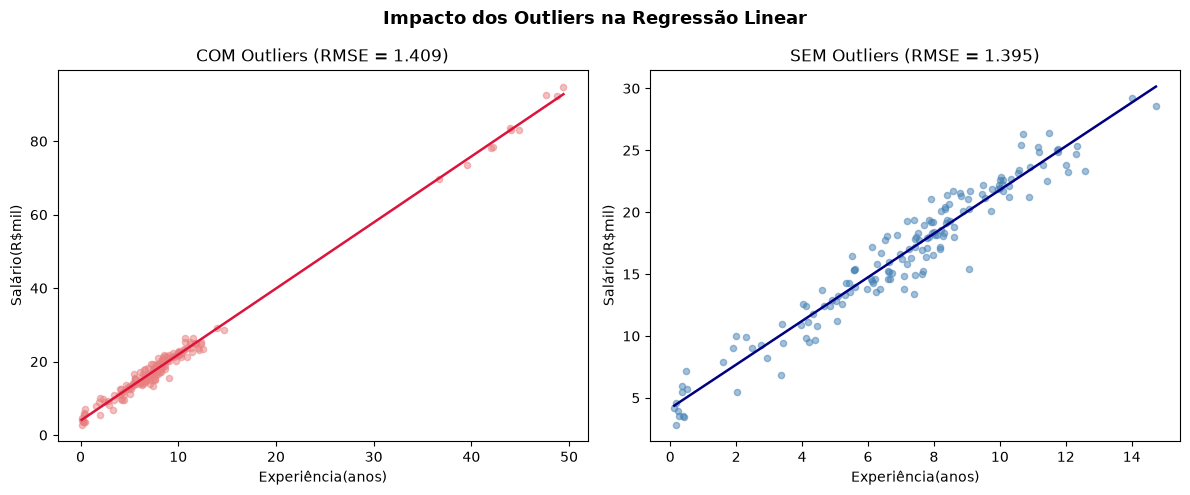

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
grafico_regressao(ax1, df, modelo_bruto, "#e88080", "#DC143C",
f"COM Outliers (RMSE = {modelo_bruto['rmse']:.3f})",
equacao=False, alpha=0.5)

grafico_regressao(ax2, df_limpo, modelo_limpo, "steelblue", "navy",
f"SEM Outliers (RMSE = {modelo_limpo['rmse']:.3f})",
equacao=False, alpha=0.5)

fig.suptitle("Impacto dos Outliers na Regressão Linear",
fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [58]:
def variacao(chave):
    return (modelo_limpo[chave]-modelo_bruto[chave]) / abs(modelo_bruto[chave])* 100

metricas =[("Intercepto(￿￿)","b0"),("Coeficiente(￿￿)", "b1"),
("**R²**","r2"),("**RMSE(R\\$mil)**", "rmse")]

comparativo = pd.DataFrame(
    [[nome,f"{modelo_bruto[k]:.4f}",f"{modelo_limpo[k]:.4f}"] for nome,k in metricas]
    + [["N amostral",str(modelo_bruto["n"]),str(modelo_limpo["n"])]],
    columns=["Métrica", "ComOutliers", "SemOutliers"],
    )

tabela_markdown(comparativo,"lrr", "Comparaçãodosmodelosderegressão")
print(f"VariaçãodoRMSEapósremoção:{variacao('rmse'):+.2f}%")
print(f"Variaçãodo R² apósremoção:{variacao('r2'):+.2f}%")
print(f"Variação do após remoção: {variacao('b1'):+.2f}%")

|Métrica | ComOutliers | SemOutliers |
|:---|---:|---:|
| Intercepto(￿￿) | 3.9143 | 4.1607 |
| Coeficiente(￿￿) | 1.7986 | 1.7634 |
| **R²** | 0.9928 | 0.9393 |
| **RMSE(R\$mil)** | 1.4095 | 1.3952 |
| N amostral | 170 | 160 |

:Comparaçãodosmodelosderegressão

VariaçãodoRMSEapósremoção:-1.01%
Variaçãodo R² apósremoção:-5.39%
Variação do após remoção: -1.96%


#### Conclusões Exercício 1
* Ao final do exercício 1, fica muito evidente o quanto a existência de outliers afeta um processo de análise de dados. Além de deixar a visualização precária (pois ele comprime a parte do gráfico onde a maioria dos dados estão, piorando sua análise) a existência desses outliers também causa uma deviação notável quando utilizando o data set para qualquer cálculo, como é observado pela variação notável do coeficiente angular na hora de calcular a regressão linear com vs sem os outliers.

* Esse problema é importante pois, em uma situação real, esses outliers podem causar uma conclusão errada ou afetar o poder preditivo da análise. Como ficou evidente, os outliers estavam causando uma diminuição no coeficiente angular, o que resultaria em qualquer previsão feita com base nessa regressão linear fique menos precisa, com resultados em y ficando, em média, menores do que realmente são.

#### Questão 2: Estimativa de Salário com o Modelo de Regressão
Utilizando o modelo ajustado com os dados sem outliers (modelo confiável), estime o salário
esperado para funcionários com diferentes tempos de experiência profissional.

##### 2.1: Estimativas Pontuais
A equação do modelo limpo é:
        $\hat{y} = 𝛽0 + 𝛽1 * x $

onde x = anos de experiência e $\hat{𝑦}$ = salário estimado em R$ mil.

Calcule o salário estimado para: 2, 5, 8, 12 e 18 anos de experiência.

In [59]:
anos_consulta = np.array([2, 5, 8, 12, 18])
salarios_estimados = predict(modelo_limpo, anos_consulta)
resultado = pd.DataFrame({
"Experiência (anos)": anos_consulta,
"Salário estimado (R\\$ mil)": np.round(salarios_estimados, 2),
})

print("=" * 50)
print(" ESTIMATIVAS DE SALÁRIO — MODELO SEM OUTLIERS")
print(f" Equação: Salário = {modelo_limpo['b0']:.2f} + {modelo_limpo['b1']:.4f} × Exp.")
print("=" * 50)
tabela_markdown(resultado, "cc", "Estimativas de salário por anos de experiência")

 ESTIMATIVAS DE SALÁRIO — MODELO SEM OUTLIERS
 Equação: Salário = 4.16 + 1.7634 × Exp.


|Experiência (anos) | Salário estimado (R\$ mil) |
|:---:|:---:|
| 2 | 7.69 |
| 5 | 12.98 |
| 8 | 18.27 |
| 12 | 25.32 |
| 18 | 35.9 |

:Estimativas de salário por anos de experiência

##### 2.2: Visualização das Estimativas
Gráfico com a reta de regressão limpa e os pontos estimados destacados.

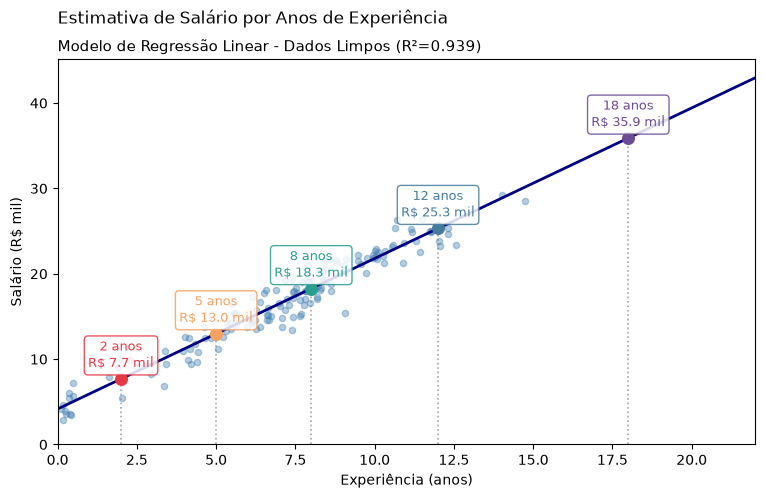

In [61]:
cores =["#e63946", "#f4a261", "#2a9d8f", "#457b9d", "#6a4c93"]
fig,ax= plt.subplots(figsize=(9, 5))

#Dados reais
ax.scatter(df_limpo["Experiencia"],df_limpo["Salario"],
color="steelblue",alpha=0.4,s=20)

#Retade regressãoestendidade0a22
xs = np.linspace(0, 22, 100)
ax.plot(xs, predict(modelo_limpo,xs),color="navy",linewidth=2)

for x, y, cor in zip(anos_consulta,salarios_estimados,cores):
    # Linha de projeção pontilhada
    ax.vlines(x, 0,y,colors="gray",linestyles="dotted",linewidth=1.2,alpha=0.7)
    # Ponto estimado
    ax.scatter(x, y,color=cor,s=70,zorder=3)
    # Rótulo
    ax.text(
    x, y +0.9, f"{x} anos\nR$ {y:.1f} mil",
    color=cor, fontsize=9,ha="center",va="bottom",
    bbox=dict(boxstyle="round",facecolor="white",alpha=0.85,edgecolor=cor),
    )

ax.set_xlim(0,22)
ax.set_ylim(bottom=0)
fig.suptitle("Estimativa de Salário por Anos de Experiência",x=0.125,ha="left")
ax.set_title(f"Modelo de Regressão Linear - Dados Limpos (R²={modelo_limpo['r2']:.3f})", loc="left",fontsize=11)
ax.set_xlabel("Experiência (anos)")
ax.set_ylabel("Salário (R$ mil)")
plt.show()

##### 2.3:  Interpretação dos Coeficientes
Responda às perguntas abaixo com base no modelo ajustado sem outliers.

In [65]:
b0,b1, r2= modelo_limpo["b0"],modelo_limpo["b1"],modelo_limpo["r2"]
print("="*55)
print(" INTERPRETAÇÃO DO MODELO")
print("="*55)
print(f" Equação: Salário = {b0:.2f} + {b1:.4f} × Experiência\n")
print(f"    = {b0:.2f} R$ mil")
print("    → Salário estimado de um profissional com")
print(" zero anos de experiência.\n")
print(f"     = {b1:.4f} R$ mil /ano")
print("    → A cada 1 ano adicional de experiência,")
print(f"     o salário aumenta em média {b1:.2f} R$ mil.\n")
print(f" R² = {r2:.4f}")
print(f"   → {r2 *100:.1f}% da variação do salário é explicada")
print("      pelos anos de experiência.")
print("="*55)

 INTERPRETAÇÃO DO MODELO
 Equação: Salário = 4.16 + 1.7634 × Experiência

    = 4.16 R$ mil
    → Salário estimado de um profissional com
 zero anos de experiência.

     = 1.7634 R$ mil /ano
    → A cada 1 ano adicional de experiência,
     o salário aumenta em média 1.76 R$ mil.

 R² = 0.9393
   → 93.9% da variação do salário é explicada
      pelos anos de experiência.


#### Conclusão Exercício 2
Na segunda parte desse laboratório, foi utilizado o método da regressão linear para descobrir a fórmula de uma reta, a reta o mais próximo de cada ponto no dataset possível (menor somatória de resíduos). Uma vez com essa fórmula, é possível achar o salário (y) para qualquer quantidade de anos de experiência (x).

Isso permite uma previsão confiável de dados que não estavam no dataset original. Porem, como observado no exercício anterior, o cálculo da regressão linear deve ser feito utilizando uma base de dados limpa, esvaziada de quaisquer outliers, caso contrário os valores podem ser deturpados e a previsão menos precisa do que ela poderia ser.